# KNearestNeighbors

Used for both regression and classification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import load_iris
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score

## What is a non parametric method?
- Make **minimal assumptions** about the data or form of the function $ f(x) $. Don't assume known form (e.g., no linear relation assumption).
- Algorithm **learn from data itself** without predefined mapping function. Are **flexible** and adapt their fit as more data becomes available.
- Non-parametric methods **require lots of data to search space of all functions**. Allow the **complexity of the model to grow** with the number of data points.
  - More data → eliminate wrong functions faster.
- Traditional models select a set of features and then impose fixed, global relationship (e.g., linear, quadratic, or cubic) between inputs and outputs. The flexibility of these models is limited by the model form chosen ahead of time.
- Non‑parametric models usually do have hyperparameters (though not always). They **may or may not explicitly use an “error” term; sometimes they optimize some other quantity instead**. Examples of non‑parametric models are:
  - K‑Nearest Neighbors (KNN), one of the simplest machine learning algorithms
  - Decision trees, which use a tree‑like model
  - Support Vector Machines (SVMs), **which use distances to a decision boundary or hyperplane**
  
**Nonparametric Methods Summary**  

These methods are highly flexible their complexity grows as more data is available. They don't require a global functional form; instead, the data itself determines the model's shape. kNN is one such non parametric method.

### What is a local fit and a global fit?

- **Global fitting** (like fitting a single line or curve) attempts to summarize the entire dataset with one equation, which can underfit some regions and overfit others.
- **Local fitting** means adapting the model to different structures in different input regions, like capturing the linear trend for small houses, flat pricing for mid-sized homes, and rapidly increasing prices for large homes.

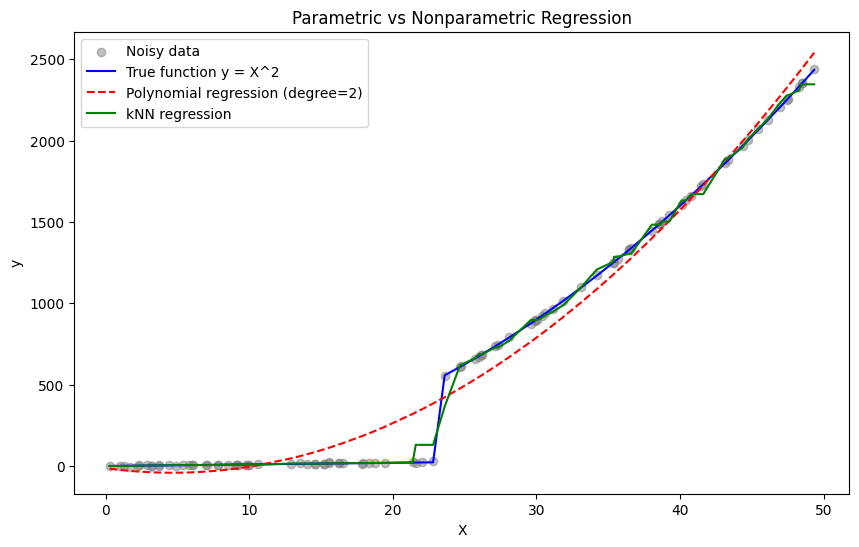

In [ ]:
# Create synthetic nonlinear data
np.random.seed(42)
X = np.expand_dims(np.sort(np.random.uniform(0, 50, 100)), axis = 1)
# y1 = X
y_true1 = X[:50]
# y2 = X^2
y_true2 = X[50:]**2
y_true = np.vstack((y_true1, y_true2)).ravel()
noise = np.random.normal(scale=3, size=y_true.shape)
y = y_true + noise

# 1. Parametric approach: Polynomial regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# 2. Nonparametric approach: kNN regression
knn_reg = KNeighborsRegressor()
knn_reg.fit(X, y)
y_knn_pred = knn_reg.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Noisy data')
plt.plot(X, y_true, color='blue', label='True function y = X^2')
plt.plot(X, y_poly_pred, color='red', linestyle='--', label='Polynomial regression (degree=2)')
plt.plot(X, y_knn_pred, color='green', linestyle='-', label='kNN regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Parametric vs Nonparametric Regression')
plt.legend()
plt.show()

**What this shows**
- The **polynomial regression** (parametric) fits the general shape but struggles to capture fine details or adapt locally because it is constrained to a quadratic polynomial.
- The **kNN regression** (nonparametric) adapts more locally: it averages nearby points dynamically and can capture more complex curves as more data points appear, illustrating how model complexity grows with data.

### Non parametric vs Parametric methods

**Noise free data (ASSUMPTION)**

- Assume:
  - Data points lie **exactly** on the true function (no noise).
  - As the number of data points increases:
    - The **mean squared error (MSE)** of 1-NN regression approaches **zero**.
      - Both **bias** and **variance** go to zero.
    - The 1-NN fit approaches the true function (blue curve) increasingly closely as more points are added.
    - In the limit of infinite data, 1-NN regression matches the true function perfectly.
  - **Contrast with parametric models (e.g., quadratic fit):**
    - Even with infinite data, a quadratic fit cannot perfectly represent functions it’s not designed for (e.g., sinusoidal curves).
    - This leads to **persistent bias** in parametric fits, regardless of data quantity.



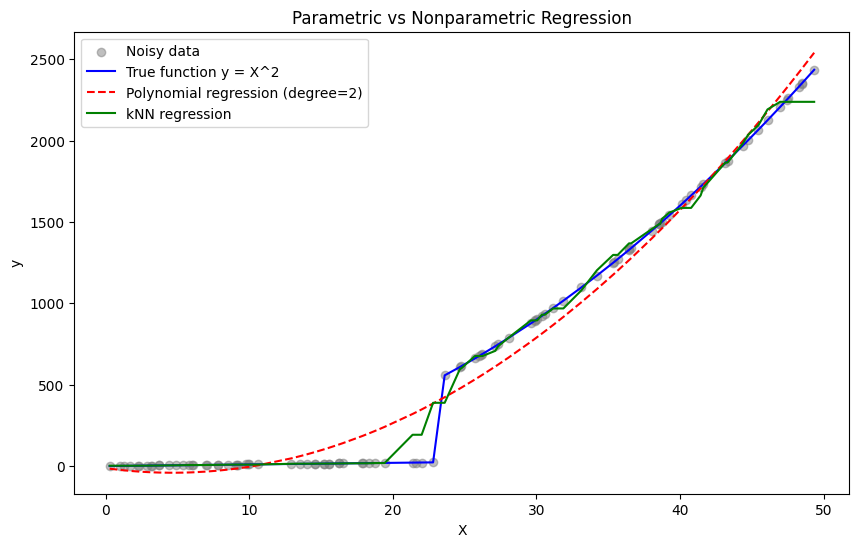

In [ ]:
# Create synthetic nonlinear data
np.random.seed(42)
X = np.expand_dims(np.sort(np.random.uniform(0, 50, 100)), axis = 1)
# y1 = X
y_true1 = X[:50]
# y2 = X^2
y_true2 = X[50:]**2
y_true = np.vstack((y_true1, y_true2)).ravel()
y = y_true

# 1. Parametric approach: Polynomial regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# 2. Nonparametric approach: kNN regression
knn_reg = KNeighborsRegressor(10)
knn_reg.fit(X, y)
y_knn_pred = knn_reg.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Noisy data')
plt.plot(X, y_true, color='blue', label='True function y = X^2')
plt.plot(X, y_poly_pred, color='red', linestyle='--', label='Polynomial regression (degree=2)')
plt.plot(X, y_knn_pred, color='green', linestyle='-', label='kNN regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Parametric vs Nonparametric Regression')
plt.legend()
plt.show()

**Noisy Data Scenario**

- When data contains **noise (random errors)**:
  - The MSE of 1-NN regression **does not** go to zero if $ k = 1 $ is fixed.
  - The 1-NN fit is **very sensitive to noise**, resulting in erratic predictions.
- To deal with noise effectively:
  - **Increase $ k $ (the number of neighbors) with the number of observations**.
  - This smooths predictions and **reduces variance** because:
    - Averaging neighbors balances out noise.
  - Hence, MSE declines toward zero when $ k \to \infty $ as data grows.

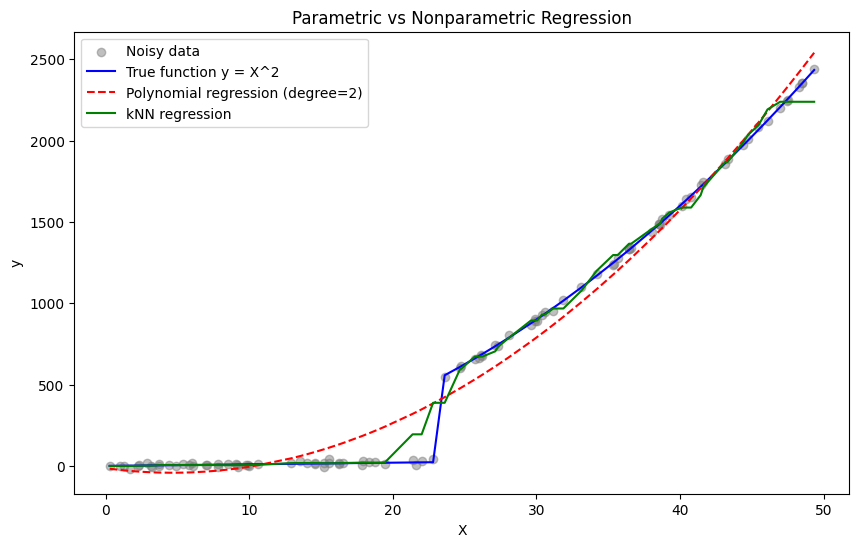

In [ ]:
# Create synthetic nonlinear data
np.random.seed(42)
X = np.expand_dims(np.sort(np.random.uniform(0, 50, 100)), axis = 1)
# y1 = X
y_true1 = X[:50]
# y2 = X^2
y_true2 = X[50:]**2
y_true = np.vstack((y_true1, y_true2)).ravel()
noise = np.random.normal(scale=10, size=y_true.shape)
y = y_true + noise

# 1. Parametric approach: Polynomial regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_poly_pred = poly_reg.predict(X_poly)

# 2. Nonparametric approach: kNN regression
knn_reg = KNeighborsRegressor(10)
knn_reg.fit(X, y)
y_knn_pred = knn_reg.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Noisy data')
plt.plot(X, y_true, color='blue', label='True function y = X^2')
plt.plot(X, y_poly_pred, color='red', linestyle='--', label='Polynomial regression (degree=2)')
plt.plot(X, y_knn_pred, color='green', linestyle='-', label='kNN regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Parametric vs Nonparametric Regression')
plt.legend()
plt.show()

### Summary

| Model Type              | Bias                      | Variance                          | MSE Behavior with Infinite Data      |
|------------------------|--------------------------|---------------------------------|-------------------------------------|
| 1-NN (k fixed at 1)    | Low bias (approaches 0)   | High variance (sensitive to noise) | MSE does **not** approach zero if data is noisy |
| k-NN (k increases with data) | Low bias (approaches 0)   | Reduced variance (due to averaging) | MSE approaches zero even with noise |
| Parametric (e.g., quadratic) | Fixed bias (model misfit) | Low variance                     | MSE approaches fixed non-zero value due to bias |

### Why do we need non parametric methods?

-  In many real-world datasets, the relationship between input (e.g., house size) and output (e.g., price) changes across the space—so a single, global model is inadequate.
- Ideally, you want a model that flexibly adapts to local structure **without having to define where those structural changes occur**.
  - KNN allow the model’s flexibility to increase with data, fitting local variation well.
  - The trade-off: **they require a lot of data** to work effectively, since they “borrow strength” from nearby points to make predictions rather than imposing a fixed global relation.


**Conclusion:**  
  Nonparametric methods offer a simple but powerful way to model complex relationships by focusing on local fits rather than a single global equation, providing better flexibility as data increases.

## Introduction to KNN

- **Definition:**  
  k-Nearest Neighbors (KNN) is a simple, instance-based machine learning algorithm - **For every input query, it identifies the k most similar instances from the training data and bases its prediction on their outcomes.**
  
  k-NN generalizes 1-NN: Averaging over k similar neighbors reduces sensitivity to outliers. Averaging over k neighbors helps the model cope with noise, producing a more stable and reasonable fit across the data compared to the highly variable 1-NN fit.

  The process emphasizes local information for more robust and realistic predictions, especially in the presence of noise or peculiarities in individual cases.

  - It assigns an output class to a new observation by examining the most similar observations in the training data.
  - “Similarity” is typically defined using distance metrics such as Euclidean distance.

## Intuition: How KNN Assigns Classes

- KNN evaluates the input features of a new observation and compares them with those of the training examples.
- KNN doesn't have a training phase as it memorizes the entire training dataset. KNN is a memory-based method: it retains all training data in memory.
- The algorithm looks at the K closest observations (neighbors).
- The new observation is assigned the class that is most frequent among its K nearest neighbors.
- The output is typically a mean (regression) or majority vote (classification) over the k neighbors.

**Core Idea**:  
- Given a labeled dataset (e.g., red vs. green), we store the data during training (lazy learning).
- A new data point is represented as a numeric "feature vector."
- For a new data point, we compute distances to all training points and select the **K closest** ones.  
- The majority label among those K neighbors becomes the prediction.


## Choosing the Value of K

Choosing the right value of K is crucial to the behavior and performance of the KNN classifier. Different values of K can lead to different predictions

- **Small K (e.g., K=1):**  
  - A small K can make predictions sensitive to noise (high variance, risk of overfitting).The model is highly specific to the training data.
  - Leads to **highly flexible** boundaries
  - Captures fine-grained structure, Risk: **Overfitting** (may model noise in the data).
  - Results in 100% training accuracy, but poor generalization
  - **On dense data: 1-NN predictions can track the true underlying function closely.**
  - **On sparse/noisy data: 1-NN predictions fluctuate wildly and fail to generalize.**
  - **1-NN is very sensitive to noise and performs poorly when the input data is sparse or noisy.**
  
- **Large K (e.g., K=1000):**
  - A large k creates very generalized answers (high bias, risk of underfitting). Produces smoother, simpler boundaries
  - The model becomes more generalized.
  - Risk: **Underfitting** (may overlook important patterns).
  - Generalizes better, but may underfit complex patterns

- **Key Point:**  
  - There is a trade-off between overfitting and underfitting.
  - Small k → Low bias, high variance
  - Large k → High bias, low variance
  - Both extremes are undesirable; aim for a balanced “sweet spot” that performs well on unseen data.
  - K is a smoothing parameter, and the optimal k provides a balance between variance and bias.

## Features & Feature Engineering:

- KNN requires numeric input because it uses distance calculations—feature vectors must represent each example numerically.

- Without scaling, larger features dominate the distance calculations.

- More features can improve or complicate KNN, so dimensionality reduction and careful feature selection (feature engineering) are important.

## Guidelines for Training k-NN Models
Follow these guidelines when training k-NN models:

* Consider that **lower k values** make class boundaries more distinct while being less effective at minimizing noise, and vice versa.

* Consider **making k odd** for binary classification to avoid a tie vote.

* Consider using a **bootstrapping method of selecting k** by taking the square root of the number of examples in the dataset.

* Consider using **cross-validation to help determine a good k value**.

* Consider using k-NN when **simplicity of implementation is key**, and when working with smaller datasets.

## **k-NN Process**

1. **Load the Dataset**  
   - Since k-NN does not involve a training phase, you only need the complete dataset to start.

2. **Select the Number of Neighbors (k)**  
   - Decide on the value of k representing how many neighbors to consider for classification.

3. **Identify Nearest Neighbors**  
   - Compute the distance between the test point $ t $ and every example in the training set.  
   - Sort all training points in order of increasing distance from $ t $.  
   - Select the top k closest points as the nearest neighbors.

4. **Predict the Label**  
   - Count the class labels of these k neighbors and assign the most common label to the test point $ t $.

In scikit-learn, there are two main types of nearest neighbor algorithms:

- **k-NN (k-Nearest Neighbors):**  
  You specify the number of neighbors to consider for classification or regression.  
  - Implemented by: `KNeighborsClassifier` and `KNeighborsRegressor`.

- **r-NN (Radius-Based Neighbors):**  
  You specify a fixed radius, and all training points within this distance from a sample are considered its neighbors.  
  - Implemented by: `RadiusNeighborsClassifier` and `RadiusNeighborsRegressor`.

## Lazy learner

- KNN is often called a lazy learner. KNN does not build a model during training, but instead simply memorizes all the training data points. Whenever a prediction is needed, KNN needs to measure the distance between the test data and the memorized training data. So it takes a long time to predict.
- It's also known as instance-based learning.

### Lazy learning (instance-based learning)

- In instance-based learning, no model is built first. It simply stores all the training data and uses the stored data to make predictions on
test data or new data whenever needed.
- Instance-based learning is typically slower than model-based learning
because it must compute something between the new data points
and all training data points every time a prediction is made.
- KNN is a typical example of instance-based learning.

### Eager learning (model-based learning)


- A model is built by fitting to the training data and then used to make
predictions on the test data or new data.
- Model-based learning takes time to train, but once trained, it can
make predictions quickly. It is typically faster than instance-based
learning.
- Model-based learning often has higher prediction accuracy than
instance-based learning because the model is trained on a large
dataset and can generalize to new data.
- Most machine learning models, such as decision trees, support vector
machines, and artificial neural networks, work this way.

## Toy examples

### CLASSIFICATION: Flower Species Prediction

**Training Data** (Features: Sepal Length, Sepal Width | Label: Species)

| ID | Sepal Length (cm) | Sepal Width (cm) | Species |
|----|-------------------|------------------|---------|
| 1  | 5.1               | 3.5              | Setosa  |
| 2  | 4.9               | 3.0              | Setosa  |
| 3  | 4.7               | 3.2              | Setosa  |
| 4  | 7.0               | 3.2              | Versicolor |
| 5  | 6.4               | 3.2              | Versicolor |
| 6  | 6.9               | 3.1              | Versicolor |
| 7  | 5.5               | 2.3              | Versicolor |
| 8  | 6.5               | 2.8              | Virginica |
| 9  | 7.6               | 3.0              | Virginica |
| 10  | 6.3               | 2.5              | Virginica |
| 11  | 6.8               | 2.7              | Virginica |
| 12 | 7.2               | 3.6              | Virginica |

**New Flower to Classify**: `(6.2, 2.9)`

In [ ]:
import numpy as np

In [ ]:
# Training data
X_class = np.array([
    [5.1, 3.5], [4.9, 3.0], [4.7, 3.2],
    [7.0, 3.2], [6.4, 3.2], [6.9, 3.1], [5.5, 2.3],
    [6.5, 2.8], [7.6, 3.0], [6.3, 2.5], [6.8, 2.7], [7.2, 3.6]
])
y_class = np.array(['Setosa']*3 + ['Versicolor']*4 + ['Virginica']*5)

# Test data
new_point = np.array([[6.2, 2.9]])

In [ ]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
knn = NearestNeighbors(n_neighbors=3).fit(X_class)
distances, indices = knn.kneighbors(new_point)
distances, indices

(array([[0.31622777, 0.36055513, 0.41231056]]), array([[7, 4, 9]]))

In [ ]:
from sklearn.metrics import euclidean_distances

In [ ]:
dist = euclidean_distances(X_class, new_point)
dist

array([[1.25299641],
       [1.30384048],
       [1.52970585],
       [0.85440037],
       [0.36055513],
       [0.72801099],
       [0.92195445],
       [0.31622777],
       [1.40356688],
       [0.41231056],
       [0.63245553],
       [1.22065556]])

In [ ]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 7],
       [ 4],
       [ 9],
       [10],
       [ 5],
       [ 3],
       [ 6],
       [11],
       [ 0],
       [ 1],
       [ 8],
       [ 2]])

In [ ]:
y_class[dis_sort[:5]]

array([['Virginica'],
       ['Versicolor'],
       ['Virginica'],
       ['Virginica'],
       ['Versicolor']], dtype='<U10')

### REGRESSION: House Price Prediction

**Training Data** (Features: Size (1000 sq ft), Bedrooms | Target: Price (in 1000s))

| ID | Size | Bedrooms | Price |
|----|------|----------|-------|
| 1  | 1.5  | 3        | 300   |
| 2  | 2.0  | 3        | 320   |
| 3  | 1.8  | 2        | 290   |
| 4  | 3.0  | 4        | 450   |
| 5  | 2.5  | 3        | 380   |
| 6  | 2.8  | 4        | 420   |
| 7  | 1.9  | 2        | 310   |
| 8  | 4.0  | 5        | 550   |
| 9  | 3.5  | 4        | 480   |
| 10  | 2.2  | 3        | 350   |
| 11  | 3.2  | 4        | 460   |
| 12  | 2.7  | 3        | 400   |

**New House to Predict**: `(2.6, 3.5)`

In [ ]:
# Training data
X_reg = np.array([
    [1.5, 3], [2.0, 3], [1.8, 2], [3.0, 4], [2.5, 3],
    [2.8, 4], [1.9, 2], [4.0, 5], [3.5, 4], [2.2, 3],
    [3.2, 4], [2.7, 3]
])
y_reg = np.array([300, 320, 290, 450, 380, 420, 310, 550, 480, 350, 460, 400])

# Test data
new_house = np.array([[2.6, 3.5]])

In [ ]:
knn = NearestNeighbors(n_neighbors=5).fit(X_reg)
distances, indices = knn.kneighbors(new_house)
distances, indices

(array([[0.50990195, 0.50990195, 0.53851648, 0.64031242, 0.64031242]]),
 array([[11,  4,  5,  9,  3]]))

In [ ]:
dist = euclidean_distances(X_reg, new_house)
dist

array([[1.2083046 ],
       [0.78102497],
       [1.7       ],
       [0.64031242],
       [0.50990195],
       [0.53851648],
       [1.65529454],
       [2.05182845],
       [1.02956301],
       [0.64031242],
       [0.78102497],
       [0.50990195]])

In [ ]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 4],
       [11],
       [ 5],
       [ 9],
       [ 3],
       [10],
       [ 1],
       [ 8],
       [ 0],
       [ 6],
       [ 2],
       [ 7]])

In [ ]:
y_reg[dis_sort[:5]]

array([[380],
       [400],
       [420],
       [350],
       [450]])

In [ ]:
# Prediction
y_reg[dis_sort[:5]].mean()

np.float64(400.0)

In [ ]:
# Training data
X_reg = np.array([
    [1500, 3], [2000, 3], [1800, 2], [3000, 4], [2500, 3],
    [2800, 4], [1900, 2], [4000, 5], [3500, 4], [2200, 3],
    [3200, 4], [2700, 3]
])
y_reg = np.array([300, 320, 290, 450, 380, 420, 310, 550, 480, 350, 460, 400])

new_house = np.array([[2.6, 3.5]])

In [ ]:
knn = NearestNeighbors(n_neighbors=5).fit(X_reg)
distances, indices = knn.kneighbors(new_house)
distances, indices

(array([[1497.40008348, 1797.4006259 , 1897.40059292, 1997.40006258,
         2197.40005689]]),
 array([[0, 2, 6, 1, 9]]))

In [ ]:
dist = euclidean_distances(X_reg, new_house)
dist

array([[1497.40008348],
       [1997.40006258],
       [1797.4006259 ],
       [2997.4000417 ],
       [2497.40005005],
       [2797.40004468],
       [1897.40059292],
       [3997.40028143],
       [3497.40003574],
       [2197.40005689],
       [3197.40003909],
       [2697.40004634]])

In [ ]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 0],
       [ 2],
       [ 6],
       [ 1],
       [ 9],
       [ 4],
       [11],
       [ 5],
       [ 3],
       [10],
       [ 8],
       [ 7]])

In [ ]:
# Prediction
y_reg[dis_sort[:5]].mean()

np.float64(314.0)

In [ ]:
import matplotlib.pyplot as plt

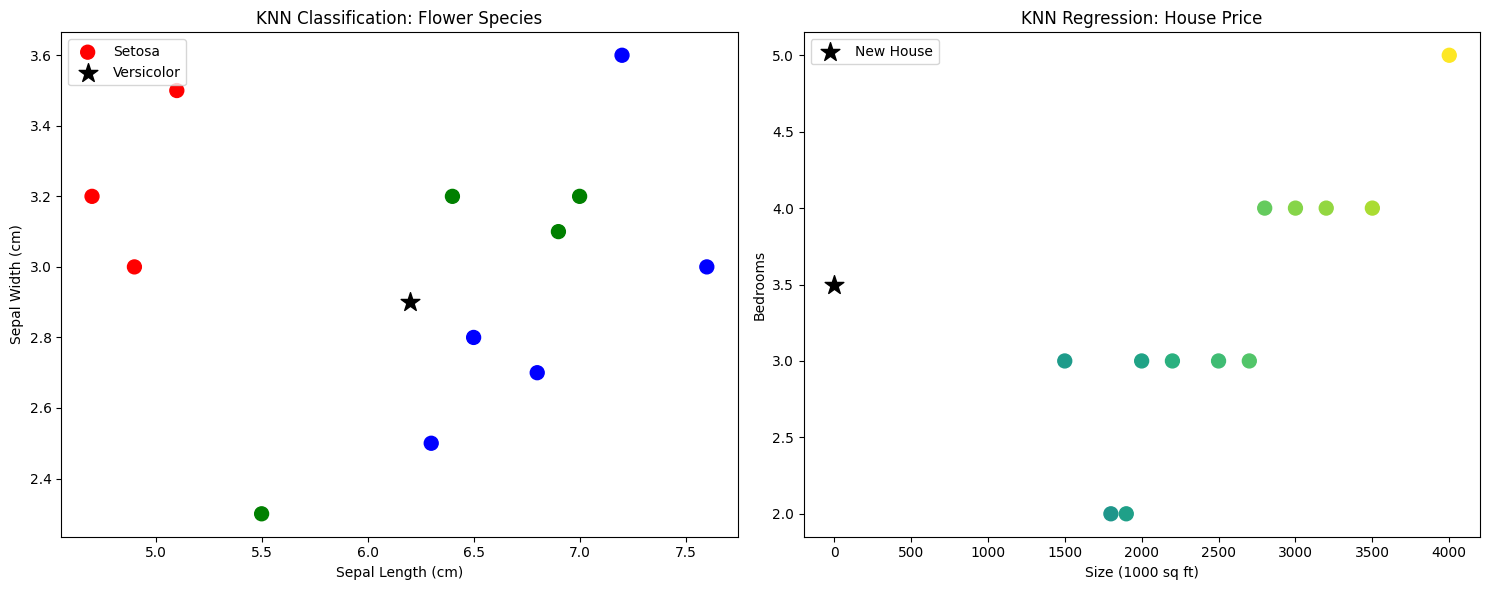

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Classification plot
class_colors = ['r']*3 + ['g']*4 + ['b']*5  # Setosa(red), Versicolor(green), Virginica(blue)
scatter1 = ax1.scatter(X_class[:,0], X_class[:,1], c=class_colors, s=100)
ax1.scatter(new_point[0,0], new_point[0,1], c='black', s=200, marker='*', label='New Point')
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')
ax1.set_title('KNN Classification: Flower Species')
ax1.legend(['Setosa', 'Versicolor', 'Virginica', 'New Point'])

# Regression plot
colors = plt.cm.viridis(y_reg / np.max(y_reg))
ax2.scatter(X_reg[:,0], X_reg[:,1], c=colors, s=100)
ax2.scatter(new_house[0,0], new_house[0,1], c='black', s=200, marker='*', label='New House')
ax2.set_xlabel('Size (1000 sq ft)')
ax2.set_ylabel('Bedrooms')
ax2.set_title('KNN Regression: House Price')
ax2.legend()

plt.tight_layout()
plt.show()

## Visualizing KNN – Example

###  Iris Dataset: KNN Classification

Suppose we have three classes in the Iris dataset:
- Class 0: Setosa
- Class 1: Versicolor
- Class 2: Virginica

In [ ]:
X, y = load_iris().data, load_iris().target
X.shape, y.shape

((150, 4), (150,))

In [ ]:
data_arr = np.hstack((X, np.expand_dims(y, axis = 1)))
data_arr

array([[5.1, 3.5, 1.4, 0.2, 0. ],
       [4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ],
       [4.6, 3.1, 1.5, 0.2, 0. ],
       [5. , 3.6, 1.4, 0.2, 0. ],
       [5.4, 3.9, 1.7, 0.4, 0. ],
       [4.6, 3.4, 1.4, 0.3, 0. ],
       [5. , 3.4, 1.5, 0.2, 0. ],
       [4.4, 2.9, 1.4, 0.2, 0. ],
       [4.9, 3.1, 1.5, 0.1, 0. ],
       [5.4, 3.7, 1.5, 0.2, 0. ],
       [4.8, 3.4, 1.6, 0.2, 0. ],
       [4.8, 3. , 1.4, 0.1, 0. ],
       [4.3, 3. , 1.1, 0.1, 0. ],
       [5.8, 4. , 1.2, 0.2, 0. ],
       [5.7, 4.4, 1.5, 0.4, 0. ],
       [5.4, 3.9, 1.3, 0.4, 0. ],
       [5.1, 3.5, 1.4, 0.3, 0. ],
       [5.7, 3.8, 1.7, 0.3, 0. ],
       [5.1, 3.8, 1.5, 0.3, 0. ],
       [5.4, 3.4, 1.7, 0.2, 0. ],
       [5.1, 3.7, 1.5, 0.4, 0. ],
       [4.6, 3.6, 1. , 0.2, 0. ],
       [5.1, 3.3, 1.7, 0.5, 0. ],
       [4.8, 3.4, 1.9, 0.2, 0. ],
       [5. , 3. , 1.6, 0.2, 0. ],
       [5. , 3.4, 1.6, 0.4, 0. ],
       [5.2, 3.5, 1.5, 0.2, 0. ],
       [5.2, 3.4, 1.4, 0.2, 0. ],
       [4.7, 3

In [ ]:
cols = load_iris().feature_names + ['target']
cols

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target']

In [ ]:
data = pd.DataFrame(data_arr, columns = load_iris().feature_names + ['target'])
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


<Axes: >

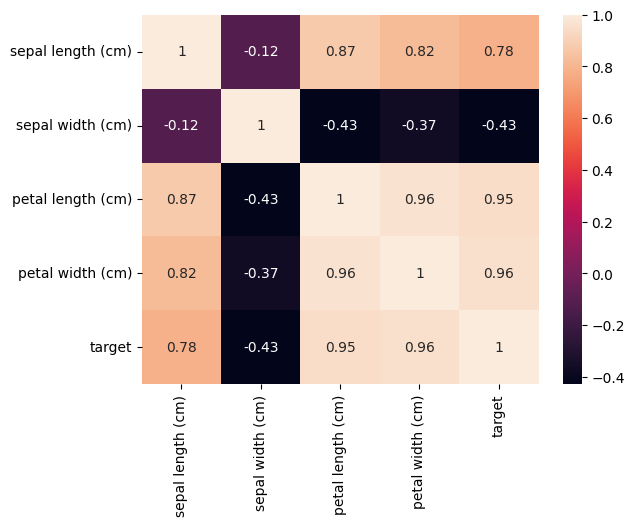

In [ ]:
corr_coeff = data.corr()
sns.heatmap(corr_coeff, annot = True)

In [ ]:
data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [ ]:
data_corr = data.drop(['petal length (cm)', 'petal width (cm)'], axis = 1)
data_corr.head()

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0.0
1,4.9,3.0,0.0
2,4.7,3.2,0.0
3,4.6,3.1,0.0
4,5.0,3.6,0.0


In [ ]:
X = data_corr.drop('target', axis = 1)
y = data_corr['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 2), (38, 2), (112,), (38,))

In [ ]:
scaler = MinMaxScaler()
X_train_transformed = scaler.fit_transform(X_train)
X_train_transformed

array([[0.55555556, 0.54166667],
       [0.38888889, 0.75      ],
       [0.66666667, 0.41666667],
       [0.36111111, 0.41666667],
       [0.38888889, 0.25      ],
       [0.22222222, 0.58333333],
       [0.72222222, 0.45833333],
       [0.52777778, 0.58333333],
       [0.58333333, 0.375     ],
       [0.47222222, 0.29166667],
       [0.52777778, 0.08333333],
       [0.41666667, 0.29166667],
       [0.38888889, 0.41666667],
       [0.19444444, 0.66666667],
       [0.55555556, 0.125     ],
       [0.19444444, 0.625     ],
       [0.72222222, 0.45833333],
       [0.33333333, 0.16666667],
       [0.38888889, 0.33333333],
       [0.55555556, 0.33333333],
       [0.52777778, 0.375     ],
       [0.41666667, 0.33333333],
       [0.69444444, 0.33333333],
       [0.55555556, 0.58333333],
       [0.19444444, 0.125     ],
       [0.58333333, 0.5       ],
       [0.66666667, 0.45833333],
       [0.69444444, 0.41666667],
       [0.44444444, 0.5       ],
       [0.22222222, 0.70833333],
       [0.

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 2, n_jobs = -1)
knn

KNeighborsClassifier(n_jobs=-1, n_neighbors=3)

In [ ]:
knn.fit(X_train_transformed, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=3)

In [ ]:
knn.score(X_train_transformed, y_train)

0.8660714285714286

In [ ]:
# Set up mesh grid for decision boundary
x_min, x_max = X_train_transformed[:, 0].min() - 0.1, X_train_transformed[:, 0].max() + 0.1
y_min, y_max = X_train_transformed[:, 1].min() - 0.1, X_train_transformed[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
xx, yy

(array([[-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        ...,
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ]]),
 array([[-0.1       , -0.1       , -0.1       , ..., -0.1       ,
         -0.1       , -0.1       ],
        [-0.09598662, -0.09598662, -0.09598662, ..., -0.09598662,
         -0.09598662, -0.09598662],
        [-0.09197324, -0.09197324, -0.09197324, ..., -0.09197324,
         -0.09197324, -0.09197324],
        ...,
        [ 1.09197324,  1.09197324,  1.09197324, ...,  

In [ ]:
# Predict class labels for each point in the mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
Z

array([[1., 1., 1., ..., 2., 2., 2.],
       [1., 1., 1., ..., 2., 2., 2.],
       [1., 1., 1., ..., 2., 2., 2.],
       ...,
       [0., 0., 0., ..., 2., 2., 2.],
       [0., 0., 0., ..., 2., 2., 2.],
       [0., 0., 0., ..., 2., 2., 2.]])

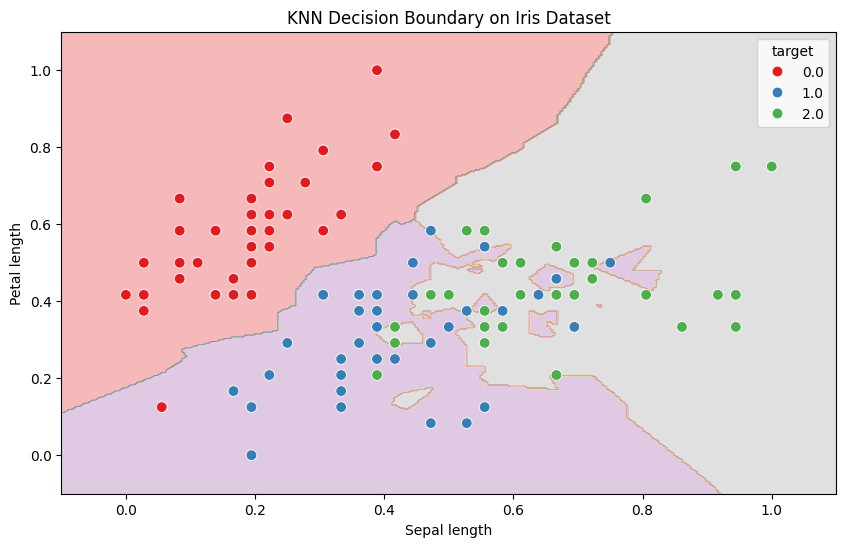

In [ ]:
# Plotting the decision boundary and data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
sns.scatterplot(x=X_train_transformed[:, 0], y=X_train_transformed[:, 1], hue=y_train, palette='Set1', s=60)
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.title('KNN Decision Boundary on Iris Dataset')
plt.legend(title='target')
plt.show()

In [ ]:
X_test_transformed = scaler.transform(X_test)
X_test_transformed

array([[0.5       , 0.33333333],
       [0.41666667, 0.29166667],
       [0.30555556, 0.70833333],
       [0.47222222, 0.375     ],
       [0.5       , 0.41666667],
       [0.16666667, 0.20833333],
       [0.41666667, 0.29166667],
       [0.16666667, 0.66666667],
       [0.55555556, 0.20833333],
       [0.66666667, 0.41666667],
       [0.16666667, 0.45833333],
       [0.83333333, 0.375     ],
       [0.11111111, 0.5       ],
       [0.94444444, 0.25      ],
       [0.13888889, 0.45833333],
       [0.33333333, 0.16666667],
       [0.5       , 0.375     ],
       [0.36111111, 0.33333333],
       [0.33333333, 0.91666667],
       [0.58333333, 0.29166667],
       [0.36111111, 0.20833333],
       [0.38888889, 0.33333333],
       [0.63888889, 0.375     ],
       [0.41666667, 0.29166667],
       [0.77777778, 0.41666667],
       [0.66666667, 0.54166667],
       [0.19444444, 0.625     ],
       [0.25      , 0.58333333],
       [0.52777778, 0.33333333],
       [0.22222222, 0.625     ],
       [0.

In [ ]:
y_pred = knn.predict(X_test_transformed)
y_pred

array([1., 2., 0., 2., 2., 1., 2., 0., 2., 2., 0., 2., 0., 2., 0., 1., 1.,
       1., 0., 2., 1., 1., 2., 2., 2., 2., 0., 0., 1., 0., 2., 0., 2., 2.,
       1., 2., 2., 2.])

In [ ]:
accuracy_score(y_pred, y_test)

0.6842105263157895

In [ ]:
load_iris().feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
def knn_predict(data, n_neighbors = 3, weights = 'uniform', drop_features = ['petal length (cm)', 'petal width (cm)']):
  data_new = data.drop(drop_features, axis = 1)
  X = data_new.drop('target', axis = 1)
  y = data_new['target']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
  X_train_transformed = scaler.fit_transform(X_train)
  knn = KNeighborsClassifier(n_neighbors = 40, metric = 'minkowski', p = 2, weights = 'uniform', n_jobs = -1)
  knn.fit(X_train_transformed, y_train)
  knn.score(X_train_transformed, y_train)

  # Set up mesh grid for decision boundary
  x_min, x_max = X_train_transformed[:, 0].min() - 0.1, X_train_transformed[:, 0].max() + 0.1
  y_min, y_max = X_train_transformed[:, 1].min() - 0.1, X_train_transformed[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
  # Predict class labels for each point in the mesh
  Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # Plotting the decision boundary and data points
  plt.figure(figsize=(10, 6))
  plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
  sns.scatterplot(x=X_train_transformed[:, 0], y=X_train_transformed[:, 1], hue=y_train, palette='Set1', s=60)
  plt.xlabel('Sepal length')
  plt.ylabel('Petal length')
  plt.title('KNN Decision Boundary on Iris Dataset')
  plt.legend(title='target')
  plt.show()

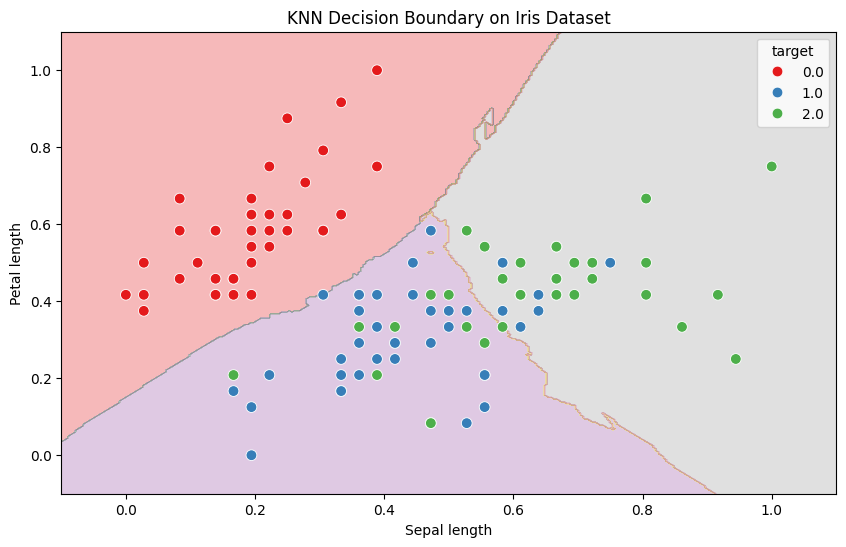

In [ ]:
knn_predict(data, n_neighbors = 20, weights = 'uniform', drop_features = ['petal length (cm)', 'petal width (cm)'])

## What is Weighted k-Nearest Neighbors?

- **Weighted k-NN** is an extension of the standard k-Nearest Neighbors method that assigns different importance (“weights”) to each neighbor based on its distance to the query (target) point.
- **Key Idea:**  Neighbors closer to the query point influence the prediction more than distant neighbors.

### Why Use Weighting?

- In standard k-NN, all k neighbors contribute equally to the prediction—abrupt changes (discontinuities) can occur when a neighbor is swapped in or out.
- **Weighted k-NN** reduces this problem: when a far away neighbor drops out, its impact was already small, so prediction changes smoothly across input space.

### How Are Weights Assigned?

- **Distance-Based Weights:**  
  - The most basic approach: weight each neighbor **inversely proportional** to its distance.
    - For neighbor $ j $ and query $ q $:
      $$
      \text{Weight}_{q,j} = \frac{1}{\text{Distance}(x_j, x_q)}
      $$
    - Closer neighbors (smaller distance) get higher weights; distant neighbors get lower weights.
- **Kernel Functions:**  
  - More generally, weights are defined by a **kernel function** of the distance between the query and each neighbor.
  - **Isotropic Kernels:** Functions that depend only on distance (not direction).
    - Examples:
      - **Gaussian Kernel (most common):**
        $$
        K_\lambda(d) = \exp\left(-\frac{d^2}{\lambda}\right)
        $$
        - $ d $ = distance, $ \lambda $ = bandwidth parameter controlling how quickly weights decay.
        - Weights never reach exactly zero—distant neighbors have vanishingly small, but nonzero, influence.
      - **Other Kernels:** Some kernels set weights to zero beyond a certain distance (window kernels).
- **Role of the Lambda ($ \lambda $) Parameter:**
  - Controls the **rate of decay**—smaller values concentrate weight near the query, larger values spread weight more broadly.

### Weighted k-NN in Higher Dimensions

- The concept generalizes:  
  - Compute distance in multi-dimensional space using your chosen distance metric.
  - Apply the kernel to this distance to get each neighbor’s weight.

### Summary

- **Weighted k-NN** smooths abrupt prediction jumps by making neighboring points influence the prediction in proportion to their similarity (distance) to the query.
- **Kernels** offer flexible ways to control how fast neighbor influence fades with distance.
- Choosing the right kernel function and decay parameter helps control bias, variance, and the locality of your predictions.

Weighted KNN

**Training Data** (Features: Sepal Length, Sepal Width | Label: Species)

| ID | Sepal Length (cm) | Sepal Width (cm) | Species |
|----|-------------------|------------------|---------|
| 1  | 5.1               | 3.5              | Setosa  |
| 2  | 4.9               | 3.0              | Setosa  |
| 3  | 4.7               | 3.2              | Setosa  |
| 4  | 7.0               | 3.2              | Versicolor |
| 5  | 6.4               | 3.2              | Versicolor |
| 6  | 6.9               | 3.1              | Versicolor |
| 7  | 5.5               | 2.3              | Versicolor |
| 8  | 6.5               | 2.8              | Virginica |
| 9  | 7.6               | 3.0              | Virginica |
| 10  | 6.3               | 2.5              | Virginica |
| 11  | 6.8               | 2.7              | Virginica |
| 12 | 7.2               | 3.6              | Virginica |

**New Flower to Classify**: `(6.2, 2.9)`

In [ ]:
import numpy as np

In [ ]:
# Training data
X_class = np.array([
    [5.1, 3.5], [4.9, 3.0], [4.7, 3.2],
    [7.0, 3.2], [6.4, 3.2], [6.9, 3.1], [5.5, 2.3],
    [6.5, 2.8], [7.6, 3.0], [6.3, 2.5], [6.8, 2.7], [7.2, 3.6]
])
y_class = np.array(['Setosa']*3 + ['Versicolor']*4 + ['Virginica']*5)

# Test data
new_point = np.array([[6.2, 2.9]])

In [ ]:
import pandas as pd

In [ ]:
datak = pd.DataFrame(X_class, columns = ['sl', 'sw'])
datak['species'] = y_class
datak

,sl,sw,species
0,5.1,3.5,Setosa
1,4.9,3.0,Setosa
2,4.7,3.2,Setosa
3,7.0,3.2,Versicolor
4,6.4,3.2,Versicolor
5,6.9,3.1,Versicolor
6,5.5,2.3,Versicolor
7,6.5,2.8,Virginica
8,7.6,3.0,Virginica
9,6.3,2.5,Virginica


In [ ]:
from sklearn.metrics import euclidean_distances

In [ ]:
datak['query_dist'] = euclidean_distances(X_class, new_point)
datak

,sl,sw,species,query_dist
0,5.1,3.5,Setosa,1.252996
1,4.9,3.0,Setosa,1.303840
2,4.7,3.2,Setosa,1.529706
3,7.0,3.2,Versicolor,0.854400
4,6.4,3.2,Versicolor,0.360555
5,6.9,3.1,Versicolor,0.728011
6,5.5,2.3,Versicolor,0.921954
7,6.5,2.8,Virginica,0.316228
8,7.6,3.0,Virginica,1.403567
9,6.3,2.5,Virginica,0.412311


In [ ]:
# Inverse of distances
datak['inv_dist'] = 1/euclidean_distances(X_class, new_point)
datak

,sl,sw,species,query_dist,inv_dist
0,5.1,3.5,Setosa,1.252996,0.798087
1,4.9,3.0,Setosa,1.303840,0.766965
2,4.7,3.2,Setosa,1.529706,0.653720
3,7.0,3.2,Versicolor,0.854400,1.170411
4,6.4,3.2,Versicolor,0.360555,2.773501
5,6.9,3.1,Versicolor,0.728011,1.373606
6,5.5,2.3,Versicolor,0.921954,1.084652
7,6.5,2.8,Virginica,0.316228,3.162278
8,7.6,3.0,Virginica,1.403567,0.712470
9,6.3,2.5,Virginica,0.412311,2.425356


In [ ]:
sort_dist = datak.sort_values('inv_dist', ascending = False)
sort_dist

,sl,sw,species,query_dist,inv_dist
7,6.5,2.8,Virginica,0.316228,3.162278
4,6.4,3.2,Versicolor,0.360555,2.773501
9,6.3,2.5,Virginica,0.412311,2.425356
10,6.8,2.7,Virginica,0.632456,1.581139
5,6.9,3.1,Versicolor,0.728011,1.373606
3,7.0,3.2,Versicolor,0.854400,1.170411
6,5.5,2.3,Versicolor,0.921954,1.084652
11,7.2,3.6,Virginica,1.220656,0.819232
0,5.1,3.5,Setosa,1.252996,0.798087
1,4.9,3.0,Setosa,1.303840,0.766965


In [ ]:
sort_dist_k = sort_dist.iloc[:5]
sort_dist_k

,sl,sw,species,query_dist,inv_dist
7,6.5,2.8,Virginica,0.316228,3.162278
4,6.4,3.2,Versicolor,0.360555,2.773501
9,6.3,2.5,Virginica,0.412311,2.425356
10,6.8,2.7,Virginica,0.632456,1.581139
5,6.9,3.1,Versicolor,0.728011,1.373606


In [ ]:
sort_dist_k.groupby('species')['inv_dist'].sum()/sort_dist_k['inv_dist'].sum()

,inv_dist
species,
Versicolor,0.366486
Virginica,0.633514


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knnd = KNeighborsClassifier(n_neighbors=5, weights='distance')
knnd.fit(X_class, y_class)  # Fit with labels!

KNeighborsClassifier(weights='distance')

In [ ]:
# Predict class + probabilities
prediction = knnd.predict(new_point)
probabilities = knnd.predict_proba(new_point)
probabilities

array([[0.        , 0.36648558, 0.63351442]])

### REGRESSION: House Price Prediction

**Training Data** (Features: Size (1000 sq ft), Bedrooms | Target: Price (in 1000s))

| ID | Size | Bedrooms | Price |
|----|------|----------|-------|
| 1  | 1.5  | 3        | 300   |
| 2  | 2.0  | 3        | 320   |
| 3  | 1.8  | 2        | 290   |
| 4  | 3.0  | 4        | 450   |
| 5  | 2.5  | 3        | 380   |
| 6  | 2.8  | 4        | 420   |
| 7  | 1.9  | 2        | 310   |
| 8  | 4.0  | 5        | 550   |
| 9  | 3.5  | 4        | 480   |
| 10  | 2.2  | 3        | 350   |
| 11  | 3.2  | 4        | 460   |
| 12  | 2.7  | 3        | 400   |

**New House to Predict**: `(2.6, 3.5)`

In [ ]:
import numpy as np

In [ ]:
# Training data
X_reg = np.array([
    [1.5, 3], [2.0, 3], [1.8, 2], [3.0, 4], [2.5, 3],
    [2.8, 4], [1.9, 2], [4.0, 5], [3.5, 4], [2.2, 3],
    [3.2, 4], [2.7, 3]
])
y_reg = np.array([300, 320, 290, 450, 380, 420, 310, 550, 480, 350, 460, 400])

# Test data
new_house = np.array([[2.6, 3.5]])

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knnd = KNeighborsRegressor(n_neighbors=5, weights = 'distance').fit(X_reg, y_reg)
knnd

KNeighborsRegressor(weights='distance')

In [ ]:
knnd.predict(new_house)

array([399.76589716])

In [ ]:
import pandas as pd

In [ ]:
house_data = pd.DataFrame(X_reg, columns = ['Size', 'Bedrooms'])
house_data['Price'] = y_reg
house_data.head()

,Size,Bedrooms,Price
0,1.5,3.0,300
1,2.0,3.0,320
2,1.8,2.0,290
3,3.0,4.0,450
4,2.5,3.0,380


In [ ]:
from sklearn.metrics import euclidean_distances

In [ ]:
dist = euclidean_distances(X_reg, new_house)
dist

array([[1.2083046 ],
       [0.78102497],
       [1.7       ],
       [0.64031242],
       [0.50990195],
       [0.53851648],
       [1.65529454],
       [2.05182845],
       [1.02956301],
       [0.64031242],
       [0.78102497],
       [0.50990195]])

In [ ]:
inv_dist = 1/dist
inv_dist

array([[0.82760589],
       [1.2803688 ],
       [0.58823529],
       [1.56173762],
       [1.96116135],
       [1.85695338],
       [0.60412209],
       [0.48737018],
       [0.97128586],
       [1.56173762],
       [1.2803688 ],
       [1.96116135]])

In [ ]:
house_data['dist'] = dist
house_data['inv_dist'] = inv_dist

In [ ]:
sort_dist = house_data.sort_values('inv_dist', ascending = False)
sort_dist

,Size,Bedrooms,Price,dist,inv_dist
11,2.7,3.0,400,0.509902,1.961161
4,2.5,3.0,380,0.509902,1.961161
5,2.8,4.0,420,0.538516,1.856953
9,2.2,3.0,350,0.640312,1.561738
3,3.0,4.0,450,0.640312,1.561738
10,3.2,4.0,460,0.781025,1.280369
1,2.0,3.0,320,0.781025,1.280369
8,3.5,4.0,480,1.029563,0.971286
0,1.5,3.0,300,1.208305,0.827606
6,1.9,2.0,310,1.655295,0.604122


In [ ]:
sort_dist_k = sort_dist.iloc[:5]
sort_dist_k

,Size,Bedrooms,Price,dist,inv_dist
11,2.7,3.0,400,0.509902,1.961161
4,2.5,3.0,380,0.509902,1.961161
5,2.8,4.0,420,0.538516,1.856953
9,2.2,3.0,350,0.640312,1.561738
3,3.0,4.0,450,0.640312,1.561738


In [ ]:
(sort_dist_k['Price']*sort_dist_k['inv_dist']).sum()/sort_dist_k['inv_dist'].sum()

np.float64(399.7658971573199)

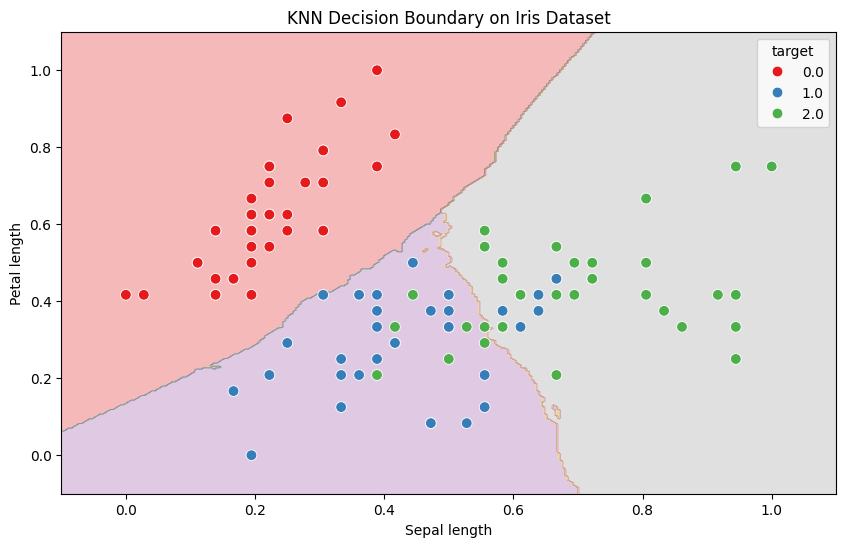

In [ ]:
knn_predict(data, n_neighbors = 2, weights = 'weights', drop_features = ['petal length (cm)', 'petal width (cm)'])

## Strengths of KNN

- **Advantages:**
  - Very simple and intuitive.
  - There is no explicit training phase—it's a "lazy learner."
  - Non-parametric: makes no assumptions about the underlying data distribution.
  - Can be used for both **classification** and **regression** tasks.
  - Easy to implement and understand.

- **Selecting K:**
  - Crucial for model performance.
  - Increasing K smooths predictions by averaging over more neighbors.

**XOR**: This dataset is a classic example of a non-linearly separable problem, which makes it a great test case for models

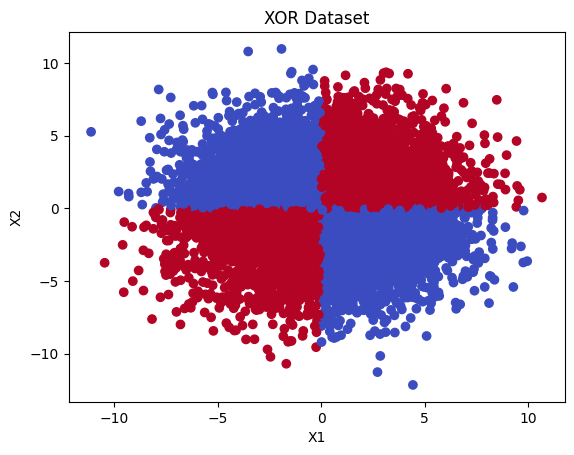

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random points
# X = np.random.uniform(low=-4, high=4, size=(400, 2))
X = np.random.normal(0, 3, size = (10000, 2))

# XOR logic based on sign of coordinates
y = np.bitwise_xor(np.sign(X[:, 0]).astype(int), np.sign(X[:, 1]).astype(int))

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('XOR Dataset')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7500, 2), (2500, 2), (7500,), (2500,))

In [ ]:
minmax = MinMaxScaler()
X_train_transformed = minmax.fit_transform(X_train)
X_train_transformed

array([[0.38173613, 0.51559393],
       [0.87316379, 0.37673925],
       [0.52322567, 0.70517732],
       ...,
       [0.45135617, 0.60950379],
       [0.58916725, 0.59876174],
       [0.44907126, 0.49537061]])

In [ ]:
knn = KNeighborsClassifier(3)
knn.fit(X_train_transformed, y_train)
knn

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Training accuracy
knn.score(X_train_transformed, y_train)

0.996

In [ ]:
X_test_transformed = minmax.transform(X_test)
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_pred, y_test)

0.9908

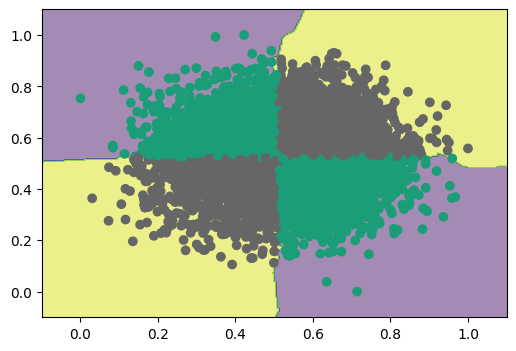

In [ ]:
  f1min, f1max = X_train_transformed[:, 0].min() - 0.1, X_train_transformed[:, 0].max() + 0.1
  f2min, f2max = X_train_transformed[:, 1].min() - 0.1, X_train_transformed[:, 1].max() + 0.1
  f1, f2 = np.meshgrid(np.linspace(f1min, f1max, 300), np.linspace(f2min, f2max, 300))
  lbl = knn.predict(np.dstack((f1.ravel(), f2.ravel())).squeeze())
  lbl = lbl.reshape(f1.shape)
  plt.figure(figsize = (6, 4))
  plt.contourf(f1, f2, lbl, alpha = 0.5)
  plt.scatter(X_train_transformed[:, 0], X_train_transformed[:, 1], c=y_train, cmap = 'Dark2')

**Donut-Shaped Synthetic Data**

This dataset consists of two concentric circles—a classic example of non-linearly separable data. It's designed to challenge classification algorithms that rely on linear decision boundaries.

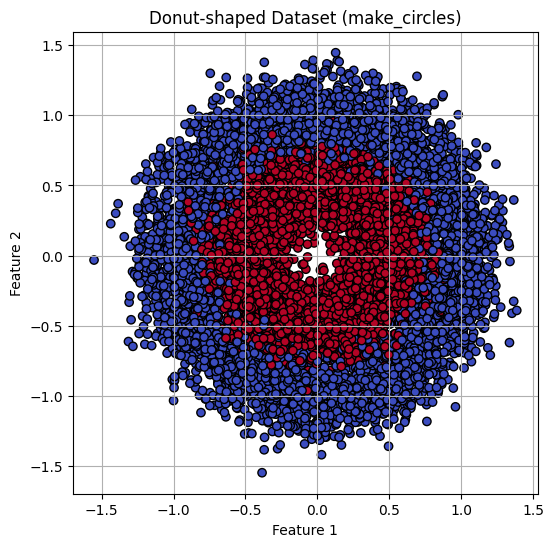

In [ ]:
# Generate donut-shaped data
X, y = make_circles(n_samples=10000, noise=0.15, factor=0.5, random_state=42)

# Visualize the dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Donut-shaped Dataset (make_circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7500, 2), (2500, 2), (7500,), (2500,))

In [ ]:
minmax = MinMaxScaler()
X_train_transformed = minmax.fit_transform(X_train)
X_train_transformed

array([[0.54045038, 0.31504523],
       [0.23815804, 0.40082499],
       [0.65830679, 0.23640128],
       ...,
       [0.44218985, 0.56466048],
       [0.53376429, 0.883157  ],
       [0.62771878, 0.49949928]])

In [ ]:
knn = KNeighborsClassifier(3)
knn.fit(X_train_transformed, y_train)
knn

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Training accuracy
knn.score(X_train_transformed, y_train)

0.9622666666666667

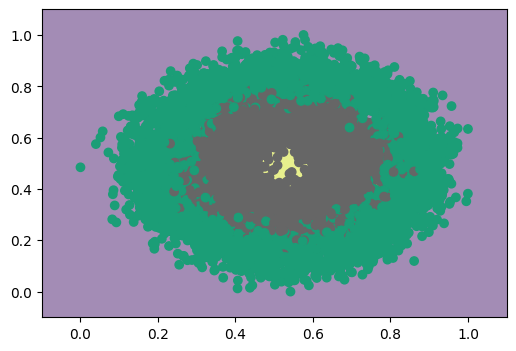

In [ ]:
  f1min, f1max = X_train_transformed[:, 0].min() - 0.1, X_train_transformed[:, 0].max() + 0.1
  f2min, f2max = X_train_transformed[:, 1].min() - 0.1, X_train_transformed[:, 1].max() + 0.1
  f1, f2 = np.meshgrid(np.linspace(f1min, f1max, 300), np.linspace(f2min, f2max, 300))
  lbl = knn.predict(np.dstack((f1.ravel(), f2.ravel())).squeeze())
  lbl = lbl.reshape(f1.shape)
  plt.figure(figsize = (6, 4))
  plt.contourf(f1, f2, lbl, alpha = 0.5)
  plt.scatter(X_train_transformed[:, 0], X_train_transformed[:, 1], c=y_train, cmap = 'Dark2')

In [ ]:
X_test_transformed = minmax.transform(X_test)
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_pred, y_test)

0.9396

**k-NN Challenges**





- **High-Dimensional Bias (Curse of Dimensionality):**  


## Limitations and Considerations

- **Disadvantages:**
  - **Scalability issues:**  
    - Performance decreases as the dataset size grows (many examples or features).
  - **Curse of dimensionality:**  
    - Effectiveness drops as the number of input variables increases.
    - In very high-dimensional spaces, all points tend to be far apart, making the concept of "nearest neighbors" less meaningful. This degrades k-NN performance because proximity no longer reliably indicates similarity.
  - **Inductive Bias:**  
     - The fundamental assumption behind k-NN is that data points close to each other in feature space share the same label. However, this assumption may not always hold true.
  - **Distance Bias:**  
    - The scale of features greatly affects distance calculations. Features with larger numeric ranges (e.g., 0 to 1000) disproportionately influence distance measures compared to features with smaller ranges (e.g., 0 to 1), potentially skewing neighbor selection.
  - **Boundary Effects:**  
    - At the data boundaries, the k nearest neighbors for several points are almost the same because there aren't enough data points on one side.
    - This causes "constant" (flat) segments at the extremes: as you move along the boundary, the set of nearest neighbors changes very little, so the predicted values remain unchanged for stretches.
  - **Discontinuity Issue (Prediction Jumps):**  
    - The k-NN regression fit can exhibit **abrupt jumps** in its predictions.
    - This happens because as you shift from one input value to the next, one neighbor may suddenly drop out and another enters, causing an immediate change in the set of neighbors averaged.
    - These jumps are especially visible when plotting the k-NN fit: the green prediction line forms a series of steps rather than a perfectly smooth curve.
    - **Why Is This a Problem?**
      - In many real-world cases (e.g., house pricing by square footage), tiny changes in input should not cause large jumps in predictions—yet k-NN can do this.
      - Visually, such discontinuities are often unattractive and counterintuitive.
  - Outliers can significantly impact distance calculations, especially if the distance metric is sensitive to extreme values. For example, the Euclidean distance is sensitive to outliers.
  - Missing data can affect the calculation of distances between data points. If features have missing values, it can lead to biased distance computations.
  - Sensitive to irrelevant features and scale of data.
  - Choosing the wrong value of K can lead to poor results.
  - KNN can be slow with large datasets (since it must compare with all training examples), and memory intensive (requires all labeled data at prediction time).
  - Sorting and maintaining a queue of k closest examples is central to efficient k-NN implementation.

The following example demonstrates a critical failure mode of the K-Nearest Neighbors (KNN) algorithm: when data points are arranged in an alternating grid pattern, KNN's reliance on spatial proximity leads to systematic misclassification. Each point is surrounded by neighbors from the opposite class, so majority voting (e.g., with k=3) consistently favors the incorrect label. This geometric setup breaks the core assumption of KNN—that nearby points share similar labels—highlighting its vulnerability in structured, alternating spatial distributions.

In [ ]:
# Creates a grid of alternating class labels.
def generate_data(height, width):
  # Initialize train and test data
  N = height*width
  # Initializes feature array X of shape (N, 2) for spatial coordinates.
  # Initializes label array y of length N.
  X = np.zeros((N, 2))
  y = np.zeros(N,)
  # Populates grid so each adjacent point alternates between class 0 and 1.
  n = 0
  start_t = 0
  for i in range(width):
    t = start_t
    for j in range(height):
      X[n] = [i, j]
      y[n] = t
      n += 1
      t = (t + 1)%2
      start_t = (start_t + 1)%2
  return X, y

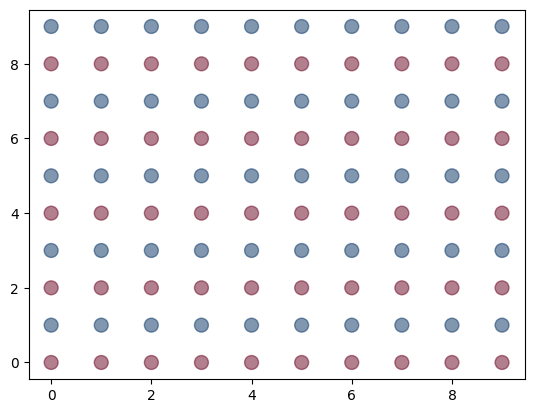

In [ ]:
X, y = generate_data(10, 10)
plt.scatter(X[:, 0], X[:, 1], s = 100, c = y, alpha = 0.5, cmap = 'RdBu')
plt.show()

In [ ]:
X, y = generate_data(100, 100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7500, 2), (2500, 2), (7500,), (2500,))

In [ ]:
minmax = MinMaxScaler()
X_train_transformed = minmax.fit_transform(X_train)
X_train_transformed

array([[0.42424242, 0.38383838],
       [0.17171717, 0.52525253],
       [0.97979798, 0.24242424],
       ...,
       [1.        , 0.66666667],
       [0.56565657, 0.51515152],
       [0.        , 0.49494949]])

In [ ]:
knn = KNeighborsClassifier(3)
knn.fit(X_train_transformed, y_train)
knn

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Training accuracy
knn.score(X_train_transformed, y_train)

0.8408

In [ ]:
X_test_transformed = minmax.transform(X_test)
y_pred = knn.predict(X_test_transformed)
accuracy_score(y_pred, y_test)

0.4028

**Baseline check**

* Creates a dummy prediction where all classes are 1.

* Calculates accuracy to compare against random guessing—revealing just how poorly KNN performs on this structured, alternating data.

In [ ]:
y_test.shape

(2500,)

In [ ]:
y_new = np.ones_like(y_test)
y_new

array([1., 1., 1., ..., 1., 1., 1.])

In [ ]:
accuracy_score(y_new, y_test)

0.5076